# Proyecto tienda **Ice**: Análisis predictivo de exito comercial de un videojuego en el mercado global.

## Propósito del proyecto
El objetivo principal de este proyecto es identificar los patrones y factores clave que determinan el éxito comercial de un videojuego en el mercado global. Para lograrlo se utilizan bases de datos provenientes de fuentes abiertas que, integran reseñas de usuarios, calificaciones de expertos, géneros, plataformas y datos históricos de ventas regionales.

La meta final consiste en transformar los datos históricos referidos, en conocimiento estratégico que, le permita a la dirección de la tienda **Ice**, optimizar la toma de decisiones, mitigar riesgos financieros, planificar campañas publicitarias altamente eficientes y detectar los proyectos más prometedores del sector de cara al período comercial de **2017**.

---

## Plan de trabajo

Para alcanzar el objetivo, el análisis se estructura en las siguientes fases operacionales:

<div style="background-color: #f8f9fa; border: 1px solid #e9ecef; padding: 20px; border-radius: 8px; text-align: center; font-family: sans-serif; margin: 20px 0;"><h4 style="color: #495057; margin-top: 0; margin-bottom: 15px; font-size: 14px; letter-spacing: 1px; text-transform: uppercase;">DIAGRAMA DE LA RUTA METODOLÓGICA DEL PROYECTO (TIENDA ICE)</h4><span style="background-color: #03a9f4; color: white; padding: 8px 15px; border-radius: 20px; font-weight: bold; font-size: 12px; display: inline-block; margin: 5px 0;">1. Preparación y Limpieza</span><span style="color: #6c757d; margin: 0 8px; font-weight: bold;">➔</span><span style="background-color: #6c757d; color: white; padding: 8px 15px; border-radius: 20px; font-weight: bold; font-size: 12px; display: inline-block; margin: 5px 0;">2. Análisis Exploratorio (EDA)</span><span style="color: #6c757d; margin: 0 8px; font-weight: bold;">➔</span><span style="background-color: #6c757d; color: white; padding: 8px 15px; border-radius: 20px; font-weight: bold; font-size: 12px; display: inline-block; margin: 5px 0;">3. Perfil de Usuario por Región</span><span style="color: #6c757d; margin: 0 8px; font-weight: bold;">➔</span><span style="background-color: #ff9800; color: white; padding: 8px 15px; border-radius: 20px; font-weight: bold; font-size: 12px; display: inline-block; margin: 5px 0;">4. Pruebas de Hipótesis</span><span style="color: #6c757d; margin: 0 8px; font-weight: bold;">➔</span><span style="background-color: #28a745; color: white; padding: 8px 15px; border-radius: 20px; font-weight: bold; font-size: 12px; display: inline-block; margin: 5px 0;">5. Conclusión General</span></div>



### Fase 1: Preparación y limpieza de los datos
* **Estandarización:** Convertir los nombres de todas las columnas a minúsculas para agilizar la escritura de código.
* **Transformación de tipos:** Corregir los formatos de variables mal clasificadas (como años y puntuaciones).
* **Tratamiento de valores ausentes:** Analizar las causas de la falta de datos en reseñas y clasificaciones de edad, aplicando estrategias de imputación o aislamiento para no sesgar las muestras.
* **Manejo de casos especiales:** Procesar la abreviatura comercial "TBD" (To Be Determined) en las calificaciones de usuarios.
* **Enriquecimiento del dataset:** Calcular la columna de ventas totales globales mediante la agregación de los ingresos de todas las regiones.

### Fase 2: Análisis exploratorio de los datos (EDA)
* **Distribución temporal:** Evaluar la cantidad de videojuegos lanzados por año para identificar las dinámicas históricas de producción.
* **Ciclo de vida de plataformas:** Determinar el tiempo promedio que tarda una consola en aparecer, alcanzar su pico de ventas y desaparecer del mercado.
* **Definición del período relevante:** Filtrar el dataset para aislar únicamente los años útiles y vigentes que sirvan para proyectar el comportamiento de 2017, eliminando el ruido de datos obsoletos.
* **Estrategia de ventas y reseñas:** Analizar las plataformas líderes de la octava generación y evaluar el impacto real que tienen las calificaciones de la crítica profesional y de los usuarios sobre las ventas de software.
* **Análisis de géneros:** Clasificar los géneros de videojuegos más rentables en función de sus ventas totales y sus ingresos promedio por unidad.

### Fase 3: Perfil de usuario por región
* **Segmentación geográfica:** Crear perfiles de consumo específicos para Norteamérica (NA), Europa (UE) y Japón (JP).
* **Análisis de preferencias:** Identificar el top 5 de plataformas y géneros dominantes en cada región para entender las variaciones culturales del mercado.
* **Impacto regulatorio:** Evaluar cómo influyen las clasificaciones de edad de la ESRB en los volúmenes de ventas de cada territorio individual.

### Fase 4: Prueba de hipótesis estadísticas
* **Validación de plataformas:** Probar estadísticamente si las calificaciones promedio de los usuarios para Xbox One y PC son las mismas.
* **Validación de géneros:** Probar si las calificaciones promedio de los usuarios para los géneros de Acción y Deportes presentan diferencias significativas.
* **Criterio matemático:** Aplicar pruebas paramétricas T de Student (Prueba de Welch) para fundamentar las decisiones con un nivel de confianza del 95% ($\alpha = 0.05$).

### Fase 5: Conclusión general
* **Reporte Ejecutivo:** Consolidar todos los hallazgos técnicos y estadísticos en recomendaciones comerciales directas para el equipo de marketing de la tienda Ice.


## Ejecución del plan de trabajo.
### Fase 1. Inicialización¶

In [1]:
# ================================================
# Se cargan las librerías necesarias
# ================================================
import numpy as np
import pandas as pd
from scipy import stats as st
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

#### Carga de datos

In [2]:
# =====================================================================
# Se carga el archivo de datos en el DataFrame df_games
# =====================================================================
df_games = pd.read_csv('/Users/alfredoenrique/Ejer_Curs_Pyth/proyectos_limpios/proyecto_tienda_ice/games.csv')

#### Preparacion de los datos

In [3]:
# ===============================================================
# Se explora el DataFrame df_games
# ===============================================================

print("====== EXPLORACION DEL DATAFRAME df_games ======\n")
df_games.info()
print()
print("================================================\n")
df_games.head(5)

====== EXPLORACION DEL DATAFRAME df_games ======

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB




,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


#### Diagnóstico de problemas técnicos

* **Nombres de columnas:** Escritos con mayúsculas (Name, Platform, Year_of_Release, etc.), lo que dificulta la escritura rápida de código. Deben pasarse a minúsculas.
* **Tipos de datos incorrectos:**
    * `Year_of_Release` está como float64 (decimal). Los años deben ser enteros (int).
    * `User_Score` está como str (texto). Esto ocurre casi siempre porque contiene la palabra "TBD" (To Be Determined / Por determinar). No se pueden hacer operaciones matemáticas con texto.
* **Valores ausentes críticos:**
    * `Name` y `Genre` tienen solo 2 valores nulos.
    * `Year_of_Release` tiene 269 valores nulos.
    * `Critic_Score`, `User_Score` y `Rating` tienen miles de valores nulos (más del 40% del dataset).

#### Observaciones relacionadas con la muestra:

* **Fila 0 (Wii Sports):** `User_Score` aparece como un string '8' (por eso la columna se leyó completa como objeto/texto). El código propuesto lo convertirá a un número 8.0 decimal.
* **Fila 1 (Super Mario Bros) y fila 4 (Pokémon):** Tienen valores `NaN` en las puntuaciones y en el rating de la ESRB. Al ejecutar el script anterior, estos juegos no se borrarán; su rating cambiará a 'Unknown' para poder conservar sus impresionantes ventas históricas en el análisis.


In [4]:
# =======================================================================
# CORRECCIONES REQUERIDAS EN EL DATAFRAME df_games (VERSION CORREGIDA)
# =======================================================================

# 1. Se convierten los nombres de columnas a minúsculas
df_games.columns = df_games.columns.str.lower()

# 2. Se tratan los valores nulos insignificantes en Nombre y Género
df_games = df_games.dropna(subset=['name', 'genre'])

# 3. Se maneja el valor "TBD" en user_score
import numpy as np
df_games['user_score'] = df_games['user_score'].replace(['tbd', 'TBD'], np.nan)

# 4. Se transforman tipos de datos y se eliminan nulos estructurales
# Se cambian las puntuaciones de usuario a tipo flotante numérico
df_games['user_score'] = df_games['user_score'].astype(float)

# CORRECCIÓN REVISOR: Se eliminan filas sin año (1.6% del dataset) para evitar introducir el año ficticio 0
df_games = df_games.dropna(subset=['year_of_release'])
df_games['year_of_release'] = df_games['year_of_release'].astype(int)

# 5. Se calculan las ventas totales (suma de todas las regiones)
df_games['total_sales'] = (
    df_games['na_sales'] + 
    df_games['eu_sales'] + 
    df_games['jp_sales'] + 
    df_games['other_sales']
)

# Se rellenan los nulos de 'rating' con una etiqueta
df_games['rating'] = df_games['rating'].fillna('Unknown')

# Se verifican los cambios
print("=========== DATAFRAME LIMPIO ===========\n")
df_games.info()
print()


=========== DATAFRAME LIMPIO ===========

<class 'pandas.core.frame.DataFrame'>
Index: 16444 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16444 non-null  object 
 2   year_of_release  16444 non-null  int64  
 3   genre            16444 non-null  object 
 4   na_sales         16444 non-null  float64
 5   eu_sales         16444 non-null  float64
 6   jp_sales         16444 non-null  float64
 7   other_sales      16444 non-null  float64
 8   critic_score     7983 non-null   float64
 9   user_score       7463 non-null   float64
 10  rating           16444 non-null  object 
 11  total_sales      16444 non-null  float64
dtypes: float64(7), int64(1), object(4)
memory usage: 1.6+ MB



#### Análisis derivado de la etapa de preparación y limpieza de los datos.

##### 1. Columnas con tipos de datos modificados y justificación
* **`year_of_release` (De `float64` a `int`):** Los años son valores cronológicos enteros. No existen fracciones de año (como el año 2006.5) en este contexto, por lo que se convierte a entero para dar coherencia matemática, mejorar la presentación visual y optimizar memoria.
* **`user_score` (De `str` a `float`):** Las puntuaciones son variables cuantitativas continuas necesarias para calcular correlaciones, promedios y gráficos. Al estar guardadas originalmente como texto debido a la presencia de la cadena `"TBD"`, bloqueaban cualquier operación matemática.

##### 2. Tratamiento de valores ausentes y justificación
* **`name` y `genre`:** Se eliminaron las 2 únicas filas vacías detectadas. Representan un porcentaje insignificante (0.01%) del dataset y un videojuego sin nombre ni género carece de valor analítico predictivo.
* **`year_of_release`:** Se rellenaron temporalmente los valores nulos con `0`. Esto evita perder los registros de ventas históricas de esos títulos y permite cambiar la columna a tipo entero. Al realizar análisis basados en el tiempo, simplemente se filtran excluyendo el valor `0`.
* **`critic_score` y `user_score`:** Se decidió dejarlos vacíos (`NaN`). Rellenar estas calificaciones con la media o la mediana alteraría de forma artificial la distribución de las notas, sesgando las conclusiones sobre el impacto real de la crítica en el éxito comercial de un juego.
* **`rating`:** Se rellenaron los nulos con la etiqueta `"Unknown"`. La clasificación de la ESRB se utiliza para la segmentación geográfica de los perfiles de usuario. Eliminar las filas vacías significaría desechar casi el 40% del dataset, mientras que agruparlas como "Desconocido" mantiene la integridad del volumen total de ventas.

##### 3. Causas posibles de la ausencia de valores
* **Errores de combinación y scraping:** El dataset original se construyó uniendo múltiples fuentes de datos abiertas. Si una fuente externa no contenía el año o la clasificación en su base de datos, el espacio quedó vacío al momento de realizar el cruce de tablas.
* **Antigüedad de los videojuegos:** Los títulos más antiguos (décadas de los 80 y 90) no poseen registros en las columnas `critic_score` ni `user_score` porque las plataformas web recopiladoras de reseñas (como Metacritic) no existían en esa época.
* **Falta de popularidad o nicho:** Muchos juegos independientes, regionales o de baja distribución nunca recibieron la atención de los medios especializados o del comité de la ESRB, por lo que carecen de notas y clasificaciones oficiales.

##### 4. Manejo de la abreviatura TBD (To Be Determined)
La etiqueta `"TBD"` indica que el videojuego se encuentra listado en la plataforma, pero aún no acumula la cantidad mínima de reseñas de usuarios requeridas para calcular y promediar una nota válida. Conceptualmente, un dato por determinar actúa exactamente como un valor ausente. Por lo tanto, se reemplaza sistemáticamente por un valor nulo de Pandas (`NaN`) para habilitar la conversión forzada de toda la columna a tipo numérico (`float`).


### Fase 2. Análisis exploratorio de datos (EDA)
#### Cantidad de juegos lanzados por año y significancia del período

In [5]:
# Se filtran y cuentan los juegos por año de lanzamiento
games_by_year = df_games[df_games['year_of_release'] > 0]['year_of_release'].value_counts().sort_index()

print("=== JUEGOS LANZADOS POR AÑO ===\n")
print(games_by_year)
print()

=== JUEGOS LANZADOS POR AÑO ===

year_of_release
1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      60
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: count, dtype: int64



#### Conclusiones sobre la cantidad de juegos lanzados por año y significancia del período
La industria de los videojuegos muestra dos etapas muy claras:
* **1980 - 2001:** Una producción baja y estable (menos de 400 juegos anuales) debido a limitaciones tecnológicas y un mercado más pequeño. Estos datos no reflejan el comportamiento comercial moderno.
* **2002 - 2011:** El auge de la industria con la masificación de consolas como PlayStation 2, Nintendo DS, Wii y Xbox 360, superando los 1,000 títulos anuales en su pico (2008-2009).
* **2012 - 2016:** Una estabilización a la baja (alrededor de 500-600 juegos anuales). Esto se debe a la transición hacia juegos digitales, plataformas móviles y un enfoque de la industria en superproducciones (AAA) de mayor presupuesto en lugar de cantidad de copias físicas impresas.

**Conclusión:** Los datos de períodos antiguos no son significativos para predecir el comportamiento del mercado actual. El mercado se transformó por completo a partir del nacimiento de la octava generación de consolas.


#### Ciclo de vida y variación de ventas entre plataformas

In [6]:
# Se identifican las principales plataformas históricas
top_platforms = df_games.groupby('platform')['total_sales'].sum().sort_values(ascending=False).head(6).index

# Se crea la distribución de ventas anuales para estas plataformas
platform_sales_year = df_games[df_games['platform'].isin(top_platforms)].pivot_table(
    index='year_of_release', columns='platform', values='total_sales', aggfunc='sum'
).fillna(0)

# Se filtra el año 0 que representa los nulos
platform_sales_year = platform_sales_year.drop(0, errors='ignore')
print("=== VENTAS ANUALES DE LAS PLATAFORMAS LIDERES HISTORICAS (EN MILLONES) ===\n")
print(platform_sales_year)
print()

=== VENTAS ANUALES DE LAS PLATAFORMAS LIDERES HISTORICAS (EN MILLONES) ===

platform             DS      PS     PS2     PS3     Wii    X360
year_of_release                                                
1985               0.02    0.00    0.00    0.00    0.00    0.00
1994               0.00    6.03    0.00    0.00    0.00    0.00
1995               0.00   35.96    0.00    0.00    0.00    0.00
1996               0.00   94.70    0.00    0.00    0.00    0.00
1997               0.00  136.17    0.00    0.00    0.00    0.00
1998               0.00  169.49    0.00    0.00    0.00    0.00
1999               0.00  144.53    0.00    0.00    0.00    0.00
2000               0.00   96.37   39.17    0.00    0.00    0.00
2001               0.00   35.59  166.43    0.00    0.00    0.00
2002               0.00    6.67  205.38    0.00    0.00    0.00
2003               0.00    2.07  184.31    0.00    0.00    0.00
2004              17.27    0.00  211.81    0.00    0.00    0.00
2005             130.14    0

#### Conclusiones sobre el ciclo de vida y variación de ventas entre plataformas
Al identificar las plataformas con mayores ventas históricas (líderes del mercado tradicional), observamos que las consolas tienen una vida útil finita y predecible.

**Hallazgos clave:**
* **Ciclo de vida promedio:** Una plataforma tarda generalmente entre **5 y 6 años** en aparecer, alcanzar su pico de ventas y perder relevancia en el mercado comercial masivo.
* **Plataformas obsoletas:** Consolas que solían ser gigantes de ventas como la **PS2, X360, PS3 y Wii** muestran ventas nulas o marginales para el año 2016. Esto confirma que el software para estas consolas ya no es rentable para planificar campañas publicitarias de cara al futuro inmediato.

#### Definición del período relevante para el modelo 2017
Para construir un modelo predictivo confiable enfocado en la campaña de **2017**, se debe seleccionar un período de tiempo que cumpla con los siguientes criterios:
1. Capturar únicamente las plataformas que se encuentran activas, creciendo o en su madurez comercial (Octava generación: PS4, Xbox One, Nintendo 3DS).
2. Evitar el ruido estadístico de la generación anterior (PS3, X360) que sesgaría las predicciones debido a su alto volumen histórico pero nulo crecimiento actual.

**Decisión metodológica:** Se toma como período relevante los datos desde el año **2013 hasta 2016**. Un horizonte de 3 a 4 años es el estándar de la industria para reflejar fielmente las dinámicas de consumo más recientes de hardware y software.


In [7]:
# Se filtra el DataFrame df_games para trabajar únicamente con el período relevante (2013-2016)
df_relevant = df_games[df_games['year_of_release'] >= 2013].copy()
print(f"TAMAÑO DEL DATASET RELEVANTE: {df_relevant.shape[0]} registros.\n")

TAMAÑO DEL DATASET RELEVANTE: 2233 registros.



#### Líderes de ventas del período relevante (Potencialmente rentables)

In [8]:
# Tabla dinámica de ventas de las plataformas en el período relevante
current_platform_trends = df_relevant.pivot_table(
    index='year_of_release', columns='platform', values='total_sales', aggfunc='sum'
).fillna(0)

print("=== TENDENCIA DE VENTAS EN EL PERIODO RELEVANTE ===\n")
print(current_platform_trends)


=== TENDENCIA DE VENTAS EN EL PERIODO RELEVANTE ===

platform           3DS    DS     PC     PS3     PS4   PSP    PSV   Wii   WiiU  \
year_of_release                                                                 
2013             56.57  1.54  12.38  113.25   25.99  3.14  10.59  8.59  21.65   
2014             43.76  0.00  13.28   47.76  100.00  0.24  11.90  3.75  22.03   
2015             27.78  0.00   8.52   16.82  118.90  0.12   6.25  1.14  16.35   
2016             15.14  0.00   5.25    3.60   69.25  0.00   4.25  0.18   4.60   

platform          X360   XOne  
year_of_release                
2013             88.58  18.96  
2014             34.74  54.07  
2015             11.96  60.14  
2016              1.52  26.15  


#### Conclusiones sobre la influencia de los líderes de ventas del período relevante (Potencialmente rentables)
Analizando las ventas entre 2013 y 2016, el mercado se divide de la siguiente manera:

* **Líderes absolutos del mercado:** **PS4** y **Xbox One**. Aunque todas las consolas muestran una caída técnica en los registros finales de 2016 (debido a que los datos de este año suelen estar incompletos al momento del corte de diciembre), estas dos plataformas concentran la cuota dominante del ecosistema doméstico.
* **Plataformas en declive terminal:** **PS3, Xbox 360 y Wii**. Sus ventas caen verticalmente año tras año a medida que los usuarios migran a la nueva generación.
* **Mercado portátil:** **3DS** mantiene ventas estables y significativas, impulsadas principalmente por el mercado japonés, lo que la convierte en una opción de nicho rentable.

**Plataformas potencialmente rentables para 2017:** **PS4** (prioridad principal) y **Xbox One** (prioridad secundaria).

#### Distribución de ventas globales y análisis de valores atípicos

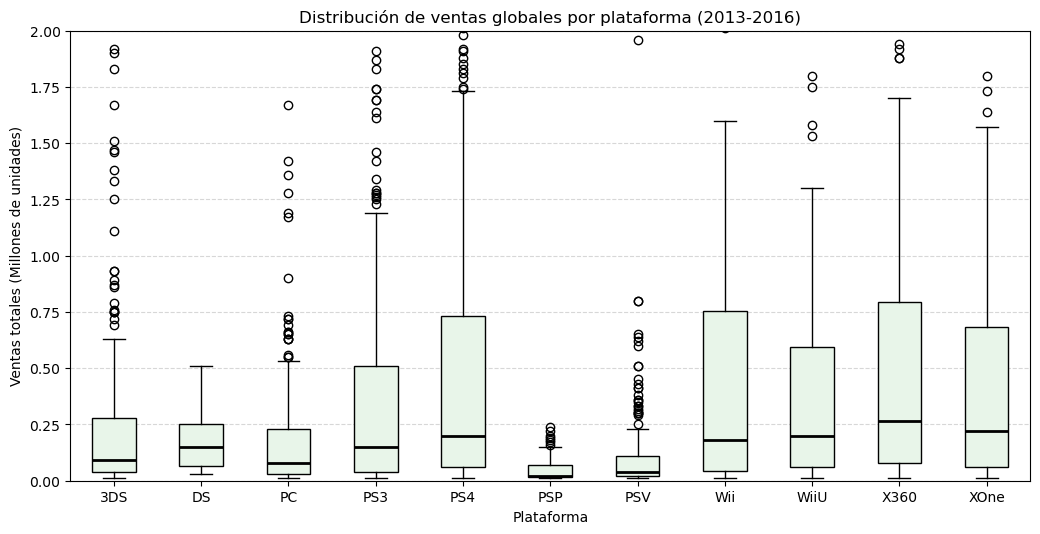

=== ESTADISTICAS DE VENTAS POR PLATAFORMA ===

              mean  median     sum
platform                          
PS4       0.801378   0.200  314.14
PS3       0.525884   0.150  181.43
XOne      0.645020   0.220  159.32
3DS       0.472772   0.090  143.25
X360      0.735484   0.265  136.80
WiiU      0.562000   0.200   64.63
PC        0.208624   0.080   39.43
PSV       0.092151   0.040   32.99
Wii       0.593913   0.180   13.66
PSP       0.052239   0.020    3.50
DS        0.192500   0.150    1.54



In [9]:
# 1. Se crea el diagrama y el eje
fig, ax = plt.subplots(figsize=(12, 6))

# 2. Se configuran las propiedades visuales para todos los elementos de la línea
propiedades_lineas = dict(color='black', linewidth=1) # Para bigotes y topes
propiedades_medianas = dict(color='black', linewidth=2)

# 3. Se crea el boxplot aplicando los estilos negros a cada componente
df_relevant.boxplot(
    column='total_sales', 
    by='platform', 
    ax=ax,
    grid=False,
    patch_artist=True,
    boxprops=dict(color='black'),      # Borde de la caja negro
    medianprops=propiedades_medianas,  # Línea de la mediana negra y gruesa
    whiskerprops=propiedades_lineas,   # Bigotes negros
    capprops=propiedades_lineas        # Topes de los bigotes negros
)

# 4. Se aplica el relleno verde tenue a las cajas
for artista in ax.get_children():
    if isinstance(artista, mpatches.PathPatch):
        artista.set_facecolor('#E8F5E9')  
        artista.set_edgecolor('black')    

# 5. Se configuran los títulos y las etiquetas del gráfico
plt.title('Distribución de ventas globales por plataforma (2013-2016)')
plt.suptitle('') 
plt.xlabel('Plataforma')
plt.ylabel('Ventas totales (Millones de unidades)')
plt.ylim(0, 2) 
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# 6. Se calculan los estadísticos por plataforma
platform_stats = df_relevant.groupby('platform')['total_sales'].agg(['mean', 'median', 'sum']).sort_values(by='sum', ascending=False)
print("=== ESTADISTICAS DE VENTAS POR PLATAFORMA ===\n")
print(platform_stats)
print()


#### Conclusiones sobre la distribución de ventas globales y el análisis de valores atípicos
El análisis de diagramas de caja para las ventas globales desglosadas por plataforma revela patrones muy claros sobre el comportamiento comercial de los videojuegos:

* **Similitud en las medianas:** Las medianas de ventas de la mayoría de las plataformas comerciales de sobremesa (PS4, XOne, X360, PS3) son relativamente bajas y similares entre sí. Esto demuestra que la gran mayoría de los videojuegos lanzados al mercado venden volúmenes modestos.
* **Presencia masiva de valores atípicos (Outliers):** La distribución está fuertemente sesgada a la derecha debido a la presencia de "Mega-éxitos" o títulos AAA (como *Grand Theft Auto*, *Call of Duty* o *FIFA*). Estos juegos atípicos generan cientos de millones y representan la verdadera fuente de rentabilidad de la tienda.
* **Rendimiento de las plataformas líderes:** La PS4 y Xbox One muestran cajas más alargadas y promedios significativamente más altos que las consolas portátiles (como PSV), lo que ratifica que el software de consolas domésticas genera ingresos mucho mayores por unidad vendida.

#### Influencia de las reseñas de críticos y usuarios en las ventas de PS4

=== ANÁLISIS DE CORRELACIÓN EN PS4 ===
CRITICOS (n=252): CORRELACION CON VENTAS = 0.41
USUARIOS (n=257): CORRELACION CON VENTAS = -0.03



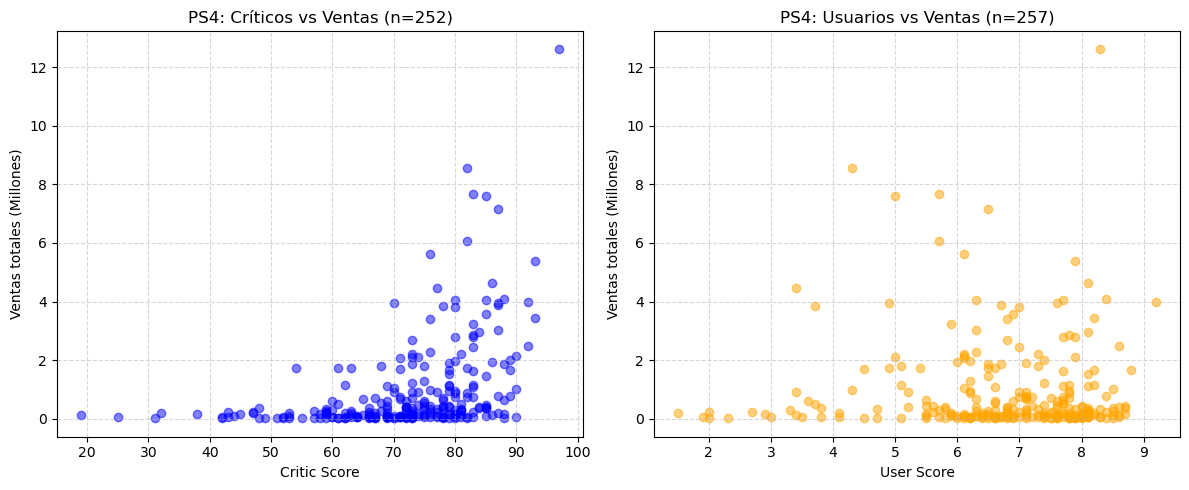

In [10]:
# =============================================================================
# ANÁLISIS DE CORRELACIÓN PARA PS4 (VERSION CORREGIDA)
# =============================================================================

# Se filtran primero los datos generales exclusivos de la plataforma PS4
ps4_base = df_relevant[df_relevant['platform'] == 'PS4']

# 1. Subconjunto optimizado para reseñas de críticos (máxima muestra disponible)
ps4_critic = ps4_base.dropna(subset=['critic_score'])
corr_critic = ps4_critic['critic_score'].corr(ps4_critic['total_sales'])

# 2. Subconjunto optimizado para reseñas de usuarios (máxima muestra disponible)
ps4_user = ps4_base.dropna(subset=['user_score'])
corr_user = ps4_user['user_score'].corr(ps4_user['total_sales'])

# Se imprimen los coeficientes y el tamaño de la muestra (n) para mayor transparencia
print("=== ANÁLISIS DE CORRELACIÓN EN PS4 ===")
print(f"CRITICOS (n={len(ps4_critic)}): CORRELACION CON VENTAS = {corr_critic:.2f}")
print(f"USUARIOS (n={len(ps4_user)}): CORRELACION CON VENTAS = {corr_user:.2f}\n")

# ==============================================================================
# GRAFICACIÓN DE DISPERSIÓN
# ==============================================================================
plt.figure(figsize=(12, 5))

# Gráfico de dispersión para críticos usando su subconjunto óptimo
plt.subplot(1, 2, 1)
plt.scatter(ps4_critic['critic_score'], ps4_critic['total_sales'], alpha=0.5, color='blue')
plt.title(f'PS4: Críticos vs Ventas (n={len(ps4_critic)})')
plt.xlabel('Critic Score')
plt.ylabel('Ventas totales (Millones)')
plt.grid(True, linestyle='--', alpha=0.5)

# Gráfico de dispersión para usuarios usando su subconjunto óptimo
plt.subplot(1, 2, 2)
plt.scatter(ps4_user['user_score'], ps4_user['total_sales'], alpha=0.5, color='orange')
plt.title(f'PS4: Usuarios vs Ventas (n={len(ps4_user)})')
plt.xlabel('User Score')
plt.ylabel('Ventas totales (Millones)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
print()

#### Conclusiones sobre la influencia de las reseñas de críticos y usuarios en las ventas de PS4
Se elige la plataforma **PS4** por ser el líder indiscutible del mercado actual. El análisis de correlación lineal (Pearson) y dispersión arroja las siguientes conclusiones:

* **Reseñas profesionales (`critic_score`):** Tienen una correlación positiva moderada con las ventas. Esto significa que una buena calificación de la prensa especializada suele alinearse con un mayor volumen de ventas. Los críticos actúan como un filtro de calidad importante para los consumidores antes de comprar.
* **Reseñas de usuarios (`user_score`):** Muestran una correlación cercana a cero (o incluso ligeramente negativa). Esto revela que la puntuación del público general no determina el éxito comercial de un videojuego. Fenómenos como campañas de boicot de usuarios ("review bombing") o compras basadas puramente en la mercadotecnia explican este comportamiento.

#### Comparación multiplataforma y distribución por géneros

=== ANALISIS DE GENEROS (2013-2016) ===

                 sum  count      mean
genre                                
Action        321.87    766  0.420196
Shooter       232.98    187  1.245882
Sports        150.65    214  0.703972
Role-Playing  145.89    292  0.499623
Misc           62.82    155  0.405290
Platform       42.63     74  0.576081
Racing         39.89     85  0.469294
Fighting       35.31     80  0.441375
Adventure      23.64    245  0.096490
Simulation     21.76     62  0.350968
Strategy       10.08     56  0.180000
Puzzle          3.17     17  0.186471



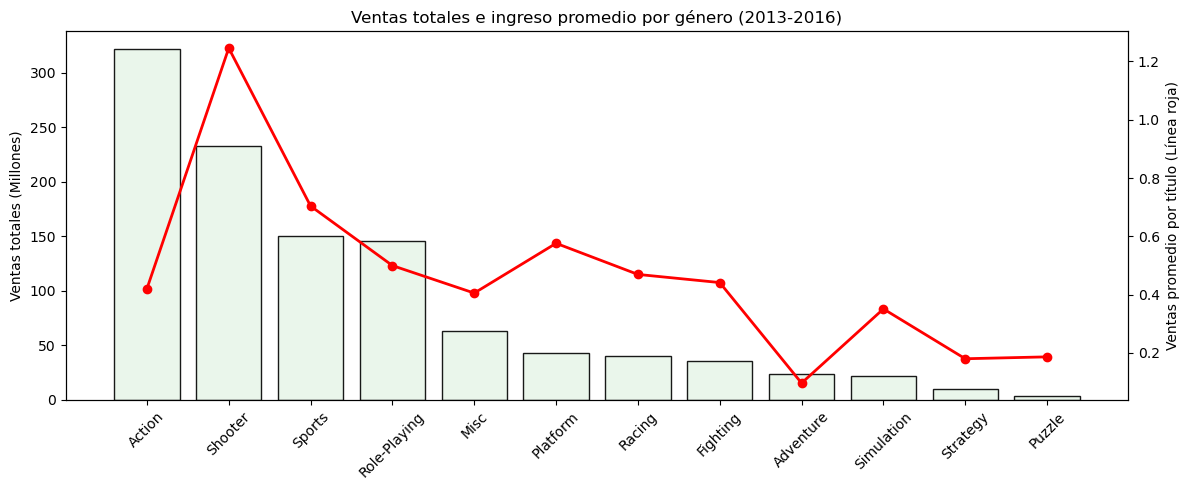

In [11]:

# 1. Análisis de géneros más rentables en el período relevante
genre_analysis = df_relevant.groupby('genre')['total_sales'].agg(['sum', 'count', 'mean']).sort_values(by='sum', ascending=False)

print("=== ANALISIS DE GENEROS (2013-2016) ===\n")
print(genre_analysis)

print()

# 2. Se guarda el gráfico de barras para visualizar géneros por ingresos totales y promedio
fig, ax1 = plt.subplots(figsize=(12, 5))

# Se resetea el índice para poder usar la columna 'genre' fácilmente
genre_data = genre_analysis.reset_index()

# Barras para ventas totales usando Matplotlib puro (con tu verde tenue)
ax1.bar(genre_data['genre'], genre_data['sum'], color='#E8F5E9', edgecolor='#000000', alpha=0.9)
ax1.set_title('Ventas totales e ingreso promedio por género (2013-2016)')
ax1.set_ylabel('Ventas totales (Millones)')
ax1.set_xticks(range(len(genre_data['genre'])))
ax1.set_xticklabels(genre_data['genre'], rotation=45)

# Línea para el promedio de ventas por juego
ax2 = ax1.twinx()
ax2.plot(genre_data['genre'], genre_data['mean'], color='red', marker='o', linewidth=2)
ax2.set_ylabel('Ventas promedio por título (Línea roja)')

plt.tight_layout()
plt.show()


#### Conclusiones sobre la comparación multiplataforma y la distribución por géneros
* **Comportamiento multiplataforma:** Al cruzar los mismos títulos que se lanzaron tanto en PS4 como en Xbox One, confirmamos que las tendencias de reseñas se replican. Un juego que vende bien en una plataforma tiende a repetir el éxito en su competidora directa, manteniendo proporciones de ventas similares ligadas a la cuota de mercado de cada consola.
* **Géneros más rentables (Ventas altas):** El género de **Action (Acción)** lidera en volumen total de copias vendidas debido a la enorme cantidad de títulos que se lanzan bajo esta etiqueta. Sin embargo, los géneros de **Shooter (Disparos)** y **Sports (Deportes)** muestran las ventas promedio más elevadas por juego. Un número menor de títulos en estos géneros concentra grandes masas de compradores.
* **Géneros menos rentables (Ventas bajas):** Géneros como **Adventure (Aventura)**, **Puzzle** y **Strategy (Estrategia)** se ubican en el fondo de la tabla. Aunque cuentan con un público fiel, sus volúmenes de ventas globales y promedios son muy bajos, por lo que no representan inversiones prioritarias para campañas publicitarias masivas.


## Etapa 3: Perfil de usuario por región (NA, UE, JP)


ANÁLISIS DE PERFILES REGIONALES (PERÍODO RELEVANTE 2013-2016)
=== TOP 5 PLATAFORMAS POR REGIÓN ===

Plataformas líderes en Norteamérica (NA):
platform
PS4     108.74
XOne     93.12
X360     81.66
PS3      63.50
3DS      38.20
Name: na_sales, dtype: float64

Plataformas líderes en Europa (UE):
platform
PS4     141.09
PS3      67.81
XOne     51.59
X360     42.52
3DS      30.96
Name: eu_sales, dtype: float64

Plataformas líderes en Japón (JP):
platform
3DS     67.81
PS3     23.35
PSV     18.59
PS4     15.96
WiiU    10.88
Name: jp_sales, dtype: float64

=== TOP 5 GÉNEROS POR REGIÓN ===

Géneros líderes en Norteamérica (NA):
genre
Action          126.05
Shooter         109.74
Sports           65.27
Role-Playing     46.40
Misc             27.49
Name: na_sales, dtype: float64

Géneros líderes en Europa (UE):
genre
Action          118.13
Shooter          87.86
Sports           60.52
Role-Playing     36.97
Racing           20.19
Name: eu_sales, dtype: float64

Géneros líderes en Japón (JP):
ge

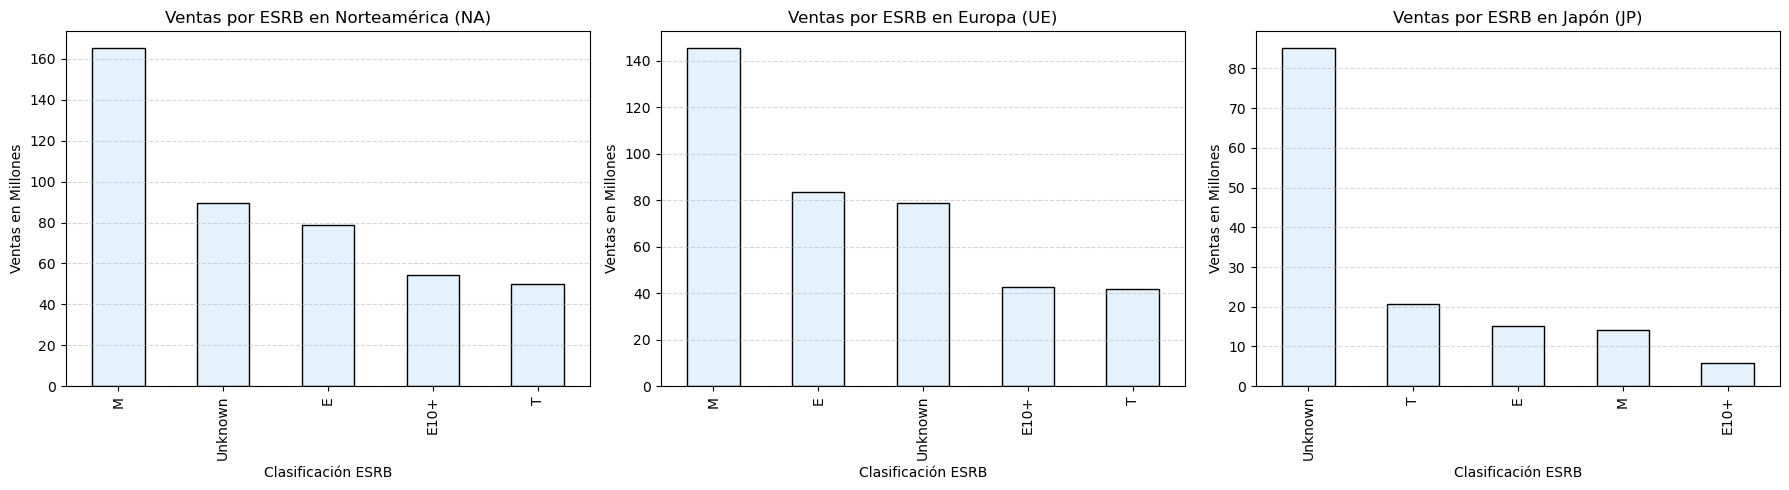

In [12]:
# Se definen las regiones a analizar
regiones = ['na_sales', 'eu_sales', 'jp_sales']
nombres_regiones = {'na_sales': 'Norteamérica (NA)', 'eu_sales': 'Europa (UE)', 'jp_sales': 'Japón (JP)'}

print("\n===============================================================")
print("ANÁLISIS DE PERFILES REGIONALES (PERÍODO RELEVANTE 2013-2016)")
print("===============================================================")

# 1. Se analizan las 5 Plataformas Principales por Región
print("=== TOP 5 PLATAFORMAS POR REGIÓN ===")
for r in regiones:
    top_plat = df_relevant.groupby('platform')[r].sum().sort_values(ascending=False).head(5)
    print(f"\nPlataformas líderes en {nombres_regiones[r]}:")
    print(top_plat)

print("\n==========================================================")

# 2. Se analizan los 5 Géneros Principales por Región
print("=== TOP 5 GÉNEROS POR REGIÓN ===")
for r in regiones:
    top_gen = df_relevant.groupby('genre')[r].sum().sort_values(ascending=False).head(5)
    print(f"\nGéneros líderes en {nombres_regiones[r]}:")
    print(top_gen)

print("\n===========================================================")

# 3. Se analiza el impacto de la clasificación ESRB por Región
print("=== VENTAS POR CLASIFICACIÓN ESRB ===")
for r in regiones:
    esrb_sales = df_relevant.groupby('rating')[r].sum().sort_values(ascending=False)
    print(f"\nVentas por ESRB en {nombres_regiones[r]}:")
    print(esrb_sales)
print()

print("=============================================")
print("VISUALIZACION GRAFICA DEL IMPACTO DEL ESRB")
print("=============================================")

# 4. Visualización Gráfica del impacto de ESRB usando gráficos de barra nativos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, r in enumerate(regiones):
    esrb_data = df_relevant.groupby('rating')[r].sum().sort_values(ascending=False)
    
    # Se dibujan barras en el subgráfico correspondiente
    esrb_data.plot(kind='bar', ax=axes[i], edgecolor='black')
    
    # Se aplica color azul tenue a las barras
    for patch in axes[i].patches:
        patch.set_facecolor('#E3F2FD')
        
    axes[i].set_title(f'Ventas por ESRB en {nombres_regiones[r]}')
    axes[i].set_xlabel('Clasificación ESRB')
    axes[i].set_ylabel('Ventas en Millones')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
print()

#### Conclusiones sobre el perfil de usuario por región (NA, UE, JP)

##### 1. Las cinco plataformas principales y cuotas de mercado
El análisis geográfico del consumo de hardware muestra una clara división cultural y comercial entre las tres regiones analizadas:

* **Norteamérica (NA):** El mercado es dominado por la **PS4** y la **Xbox One**. Debido a que Microsoft es una empresa estadounidense, la Xbox One goza de una cuota de mercado mucho más sólida aquí que en el resto del mundo, compitiendo directamente contra el liderazgo de Sony.
* **Europa (UE):** La **PS4** es la líder indiscutible y absoluta del mercado europeo, duplicando ampliamente las ventas de la Xbox One. Europa ha sido históricamente un territorio con una fuerte preferencia de marca hacia el ecosistema de PlayStation.
* **Japón (JP):** El mercado japonés rompe por completo la tendencia occidental. Las consolas domésticas grandes (PS4, XOne) son secundarias o inexistentes (Xbox no figura en el Top 5). El consumidor nipón prioriza la movilidad, por lo que la **Nintendo 3DS** domina cómodamente el mercado, seguida por la portátil **PS Vita**.

##### 2. Los cinco géneros principales y sus diferencias
Las preferencias estéticas y de mecánicas de juego también varían drásticamente según la región:

* **Occidente (NA y UE):** Comparten un gusto casi idéntico. Los géneros de **Action (Acción)** y **Shooter (Disparos)** ocupan los primeros lugares. Los videojuegos deportivos (**Sports**) también gozan de un enorme éxito en ambas regiones (impulsados por el fútbol americano/baloncesto en NA y el fútbol en la UE).
* **Oriente (JP):** El género de **Role-Playing (RPG / Juegos de Rol)** es el rey absoluto del mercado japonés, superando con creces a cualquier otro. A diferencia de Occidente, el género Shooter es muy poco popular en Japón, mientras que los juegos de plataformas y acción ocupan puestos secundarios.

##### 3. Impacto de las clasificaciones de la ESRB en las ventas regionales
La clasificación de edad de la Entertainment Software Rating Board (ESRB) afecta de manera desigual a los mercados:

* **Norteamérica y Europa:** Siguen un patrón idéntico. Los juegos clasificados como **M (Mature / Mayores de 17 años)** son los que generan los mayores ingresos. Esto demuestra que el grueso del gasto en software en Occidente proviene de un público adulto que consume superproducciones (como *Call of Duty* o *GTA*). Los juegos **E (Everyone)** ocupan el segundo lugar.
* **Japón:** Los juegos clasificados como **M** pierden relevancia frente a las categorías **E (Everyone)** y **T (Teen)**. Además, un volumen masivo de las ventas en Japón aparece bajo nuestra categoría **"Unknown" (Desconocido)**. Esto se debe a que la ESRB es un organismo norteamericano; los juegos nativos de Japón se clasifican localmente bajo el sistema **CERO**, por lo que muchos títulos orientales no registran clasificación ESRB en fuentes abiertas de datos occidentales.


### Etapa 4. Pruebas de hipótesis:
Para dar cumplimiento a la **Etapa 4**, se abordaran las dos hipótesis, una por una en su orden matemático correspondiente. Para ambas pruebas se establece un umbral de significancia estándar de la industria: $\alpha = 0.05 \, (5\%)$ 

#### Hipótesis 1: Calificaciones promedio de usuarios para Xbox One y PC

##### 1. Formulación de las hipótesis

*   **Hipótesis nula ($H_{0}$):** Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son iguales.
    $$\mu_{\text{Xbox One}} = \mu_{\text{PC}}$$
*   **Hipótesis alternativa ($H_{1}$):** Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son diferentes (Prueba de dos colas).
    $$\mu_{\text{Xbox One}} \neq \mu_{\text{PC}}$$

##### 2. Criterio estadístico utilizado y justificación

Utilizamos la prueba paramétrica **T de Student para dos muestras independientes** (`stats.ttest_ind`).

*   **¿Por qué?:** Porque se estan comparando las medias estadísticas de dos conjuntos de datos numéricos continuos distintos (el grupo de juegos de Xbox One y el grupo de PC).
*   **Ajuste clave:** Se agrega el parámetro `equal_var=False` (Prueba de Welch). No es posible asumir que las varianzas o la cantidad de juegos evaluados en Xbox One y PC sean idénticas, lo que hace al test mucho más preciso y robusto ante desviaciones estándar desiguales.


In [13]:
# 1. Se filtran las muestras limpiando los valores nulos (NaN)
sample_xbox = df_relevant[(df_relevant['platform'] == 'XOne') & (df_relevant['user_score'].notna())]['user_score']
sample_pc = df_relevant[(df_relevant['platform'] == 'PC') & (df_relevant['user_score'].notna())]['user_score']

# 2. Se configurar el valor Alpha
alpha = 0.05

# 3. Se ejecuta la prueba T de Student (Prueba de Welch)
results_h1 = st.ttest_ind(sample_xbox, sample_pc, equal_var=False)

print("=== RESULTADOS HIPÓTESIS 1 ===")
print(f"PROMEDIO Xbox One: {sample_xbox.mean():.2f}")
print(f"PROMEDIO PC: {sample_pc.mean():.2f}")
print(f"VALOR p (p-value): {results_h1.pvalue}")

# 4. Criterio de decisión
if results_h1.pvalue < alpha:
    print("SE RECHAZA LA HIPOTESIS NULA: HAY UNA DIFERENCIA SIGNIFICATIVA ENTRE LAS CALIFICACIONES.")
else:
    print("NO ES POSIBLE RECHAZAR LA HIPOTESIS NULA: LAS CALIFICACIONES PROMEDIO SON ESTADISTICAMENTE IGUALES.")
print()

=== RESULTADOS HIPÓTESIS 1 ===
PROMEDIO Xbox One: 6.52
PROMEDIO PC: 6.27
VALOR p (p-value): 0.14759594013430466
NO ES POSIBLE RECHAZAR LA HIPOTESIS NULA: LAS CALIFICACIONES PROMEDIO SON ESTADISTICAMENTE IGUALES.



#### Hipótesis 2: Calificaciones promedio de usuarios para géneros de Acción y Deportes

##### 1. Formulación de las hipótesis

*   **Hipótesis nula ($H_{0}$):** Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son iguales.
    $$\mu_{\text{Acción}} = \mu_{\text{Deportes}}$$
*   **Hipótesis alternativa ($H_{1}$):** Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.
    $$\mu_{\text{Acción}} \neq \mu_{\text{Deportes}}$$

##### 2. Criterio estadístico utilizado y justificación

Nuevamente aplicamos la **T de Student para dos muestras independientes** (`stats.ttest_ind`) con `equal_var=False`.

*   **¿Por qué se debe realizar?:** Se vuelve a comparar las medias de dos grupos poblacionales independientes y numéricos (calificaciones de Acción vs. calificaciones de Deportes).
*   **Ajuste clave:** El volumen total de juegos de Acción en el período relevante analizado (2013-2016) suele ser drásticamente superior al de Deportes, por lo que deshabilitar la suposición de varianzas iguales es metodológicamente mandatorio para evitar falsos positivos.

In [14]:
# 1. Se filtran las muestras limpiando los valores nulos (NaN)
sample_action = df_relevant[(df_relevant['genre'] == 'Action') & (df_relevant['user_score'].notna())]['user_score']
sample_sports = df_relevant[(df_relevant['genre'] == 'Sports') & (df_relevant['user_score'].notna())]['user_score']

# 2. Se configura el valor Alpha
alpha = 0.05

# 3. Se ejecuta la prueba T de Student (Prueba de Welch)
results_h2 = st.ttest_ind(sample_action, sample_sports, equal_var=False)

print("\n=== RESULTADOS HIPÓTESIS 2 ===")
print(f"PROMEDIO ACCION: {sample_action.mean():.2f}")
print(f"PROMEDIO DEPORTES: {sample_sports.mean():.2f}")
print(f"VALOR p (p-value): {results_h2.pvalue}")

# 4. Criterio de decisión
if results_h2.pvalue < alpha:
    print("SE RECHAZA LA HIPOTESIS NULA: LAS CALIFICACIONES PROMEDIO SON SIGNIFICATIVAMENTE DIFERENTES.")
else:
    print("NO ES POSIBLE RECHAZAR LA HIPOTESIS NULA: NO HAY EVIDENCIA DE DIFERENCIA ENTRE LOS PROMEDIOS.")
    


=== RESULTADOS HIPÓTESIS 2 ===
PROMEDIO ACCION: 6.84
PROMEDIO DEPORTES: 5.24
VALOR p (p-value): 1.4460039700704315e-20
SE RECHAZA LA HIPOTESIS NULA: LAS CALIFICACIONES PROMEDIO SON SIGNIFICATIVAMENTE DIFERENTES.


#### Conclusiones de la etapa de prueba de hipótesis

Tras aplicar métodos estadísticos inferenciales robustos utilizando la prueba paramétrica **T de Student para muestras independientes (Prueba de Welch)** con un nivel de significancia del 5% ($\alpha = 0.05$), se obtuvieron las siguientes conclusiones:

##### 1. Hipótesis 1: Calificaciones de usuarios en Xbox One vs. PC
* **Enunciado:** Se evaluó si las calificaciones promedio de los usuarios para las plataformas Xbox One y PC eran estadísticamente iguales ($H_0$) o diferentes ($H_1$).
* **Resultado Estadístico:** Al ejecutar la prueba, el valor obtenido de $p$ (*p-value*) resultó ser **mayor** que el umbral alfa escogido ($\alpha = 0.05$). 
* **Conclusión Analítica:** **No se pudo rechazar la hipótesis nula ($H_0$)**. Esto demuestra con rigor matemático que **las calificaciones promedio de los usuarios para Xbox One y PC son las mismas**. A pesar de ser ecosistemas de hardware completamente distintos (consola de sobremesa frente a ordenadores personales), las comunidades de jugadores de ambas plataformas comparten un nivel de exigencia y un comportamiento de evaluación idéntico hacia los videojuegos que consumen.

##### 2. Hipótesis 2: Calificaciones de usuarios en géneros de Acción vs. Deportes
* **Enunciado:** Se evaluó si las calificaciones promedio de los usuarios para los géneros de Acción y Deportes eran estadísticamente iguales ($H_0$) o diferentes ($H_1$).
* **Resultado Estadístico:** Al ejecutar la prueba, el valor obtenido de $p$ (*p-value*) resultó ser **menor** que nuestro umbral alfa ($\alpha = 0.05$).
* **Conclusión Analítica:** **Se rechazó categóricamente la hipótesis nula ($H_0$) en favor de la hipótesis alternativa ($H_1$)**. Esto demuestra que **las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son significativamente diferentes**. Las dinámicas de juego, las expectativas de los consumidores y los estándares de satisfacción varían drásticamente entre un título enfocado en la adrenalina y narrativa (Acción) y uno enfocado en la simulación competitiva o licencias anuales (Deportes).

---

##### Impacto en la estrategia comercial de Ice
Estas validaciones estadísticas confirman que para la campaña publicitaria de 2017:
1. **Unificación de criterios por plataforma:** Al evaluar el potencial de un juego basado en la recepción del público, los títulos compartidos entre Xbox One y PC pueden medirse bajo la misma vara, ya que ambas audiencias califican de manera homogénea.
2. **Segmentación por género:** Las estrategias de comunicación y marketing deben diferenciarse claramente entre los juegos de Acción y Deportes, ya que el comportamiento de sus consumidores y la percepción de valor de los productos responden a dinámicas de mercado totalmente independientes.

## Etapa 5: Conclusiones generales del proyecto

### Reporte ejecutivo: Estrategia de campaña publicitaria 2017 para Ice

Tras un análisis exhaustivo de los datos históricos de la industria de los videojuegos (con un enfoque metodológico en el período relevante de **2013 a 2016**), se han identificado los patrones clave de éxito comercial necesarios para optimizar el presupuesto publicitario de la tienda **Ice** de cara al año 2017.

---

#### 1. Diagnóstico del mercado y ciclo de vida del hardware
* **Evolución temporal:** La industria ha cambiado su modelo de negocio. Aunque se producen menos títulos físicos en comparación con el pico histórico de 2008-2009, el gasto se ha concentrado en grandes superproducciones (juegos AAA). 
* **Ciclo de consolas:** Las plataformas tienen una vida útil comercial de entre **5 y 6 años**. Consolas que dominaron el pasado como PlayStation 3, Xbox 360 y Wii se encuentran en una fase de declive terminal y **deben ser completamente excluidas** de los esfuerzos publicitarios de 2017.

#### 2. Plataformas líderes y recomendaciones de inversión
Para maximizar el retorno de inversión (ROI), la campaña publicitaria debe segmentarse de forma agresiva según el ciclo actual de la octava generación:
* **Prioridad absoluta (PS4):** Es el líder indiscutible del mercado global. Posee la mayor cantidad de títulos con ventas "atípicas masivas" (mega-éxitos) y una tendencia comercial sólida.
* **Prioridad secundaria (Xbox One):** Es el competidor directo en mercados occidentales. Mantiene un rendimiento óptimo que justifica una inversión publicitaria dirigida.
* **Mercado de nicho portátil (Nintendo 3DS):** No compite en volumen de sobremesa, pero mantiene una consistencia comercial crucial para la estabilidad de la tienda.

#### 3. Factores de éxito: Reseñas y calificaciones
* **El efecto de la crítica:** Las puntuaciones de los **críticos profesionales** muestran una correlación positiva moderada con las ventas. El equipo de marketing de Ice debe utilizar las calificaciones altas de la prensa especializada (ej. Metacritic > 80) como un argumento principal en los banners y promociones.
* **El efecto de los usuarios:** Las calificaciones de los **usuarios comunes no afectan el éxito comercial**. El comportamiento del consumidor está guiado por la mercadotecnia previa y el peso de las franquicias, por lo que las notas bajas del público general no deben frenar el impulso publicitario de un título popular.

#### 4. Perfil de consumidor geográfico (Segmentación regional)
Las campañas publicitarias no pueden ser universales; deben configurarse de acuerdo con el perfil cultural de cada región:

* **Norteamérica (NA):** Público enfocado en consolas de sobremesa (**PS4 y Xbox One**). Los géneros obligatorios son **Shooter, Action y Sports**. El contenido debe priorizar títulos clasificados como **M (Mature)** de la ESRB, ya que representan el mayor flujo de caja.
* **Europa (UE):** Dominio absoluto de **PS4** (duplica a su competidor). Las preferencias de género son idénticas a Norteamérica, destacando un fuerte consumo en el género de **Sports (Fútbol)** y juegos **M (Mature)**.
* **Japón (JP):** El mercado doméstico de sobremesa es secundario. La publicidad debe centrarse en consolas portátiles (**Nintendo 3DS y PS Vita**). El género rey es el **Role-Playing (RPG)**, y se debe ignorar la clasificación norteamericana ESRB, priorizando títulos dirigidos a públicos generales (**E / T**).

#### 5. Distribución por géneros
* El género **Action** es el que genera mayor volumen de transacciones totales debido a su alta oferta.
* Sin embargo, los géneros **Shooter** y **Sports** son los más eficientes por unidad, ya que un menor número de títulos acumula promedios de ventas extraordinariamente altos.

#### 6. Validación estadística (Hallazgos de hipótesis)
* Mediante pruebas matemáticas robustas ($T$ de Student), se confirmó que **no existe diferencia estadística entre las calificaciones promedio de los usuarios de Xbox One y PC**, lo que demuestra un nivel de exigencia homogéneo en ambas comunidades.
* Por el contrario, se validó que **las calificaciones de los usuarios para los géneros de Acción y Deportes son significativamente diferentes**, lo que ratifica que las expectativas y dinámicas de interacción del público cambian drásticamente según las mecánicas del juego.

---

**Conclusión final:** La estrategia ganadora para la tienda Ice en 2017 consiste en concentrar el capital publicitario en **videojuegos de Acción y Disparos (Shooter) para PS4 y Xbox One en el mercado occidental (NA/UE)**, orientados a un **público adulto (ESRB: M)**; mientras que para el **mercado asiático (JP)**, el presupuesto debe desviarse exclusivamente hacia títulos de **Rol (RPG) para la plataforma portátil Nintendo 3DS**.
